# Kaggle Housing Price Prediction - Linear Model

Ridge regression solution for the [Kaggle Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/competitions/home-data-for-ml-course). Predicts residential home sale prices in Ames, Iowa. The competition metric is MAE on the raw price, but the model is trained on log(SalePrice) to reduce the influence of high-value outliers. This is equivalent to minimising RMSLE.

Ridge was selected because there are ~1460 rows of data and 80-90 features (Before one-hot encoding) in the model so we don't have to worry too much about droping features. There is also significant multicollinearity between many of the columns so Ridge should handle this better than something like LASSO that would totally drop some correlated features.

Exploratory analysis and outlier identification are covered in `data-exploration.ipynb`. This notebook focuses on the modelling pipeline:

ADD PIPELINE

TODO:
- Try Huber regression. This should deal with outliers better and might help with reducing sensitivity to strange houses

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.optimize import minimize_scalar

from pandas.api.types import CategoricalDtype

from sklearn.linear_model import Ridge

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import mutual_info_regression

import joblib
import plotly
import optuna
import optuna.visualization as vis

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

## Preprocessing

In [4]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the data exploration notebook
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    # drop columns that are missing a significant amount of data
    df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType'])

    # note: FireplaceQu has >40% missing values but can be imputed with
    # ordinal encoding so might be worth keeping

    # set all the continuous variables to float dtype
    continuous_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                       'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

    df[continuous_cols] = df[continuous_cols].astype(float)

    return df


def remove_outliers(df):
    '''
    Two Edwards neighbourhood partial sales identified in data-exploration.ipynb that
    seem like outliers. Large area, good quality, but low price. Remove these
    from the training data
    '''
    mask = ((df['Neighborhood'] == 'Edwards') &
            (df['SaleCondition'] == 'Partial') &
            (df['GrLivArea'] > 4000))
    
    return df[~mask]


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats


def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(df.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig',
                       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation',
                       'Heating', 'Electrical', 'Functional', 'SaleType', 'SaleCondition',
                       'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data

Apply the full preprocessing pipeline. The `impute_stats` dict is fit on the training set and passed through to the test set so the test data never influences any computed statistics.

In [5]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train = remove_outliers(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1458, 75)
Shape of test dataset:  (1459, 74)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


In [7]:
train.select_dtypes('int').columns

Index(['MSSubClass', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MoSold',
       'YrSold', 'SalePrice'],
      dtype='object')

In [8]:
train.select_dtypes('float').columns

Index(['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype='object')

In [10]:
train.select_dtypes('category').columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

## Baseline Model

Establish a baseline score using Ridge with a default alpha parameter on the raw features before any feature engineering. The scoring function uses 5-fold cross-validation and reports RMSE on log(`SalePrice`), consistent with the competition's RMSLE metric.

In [11]:
def cat_to_codes(X):
    '''
    Convert ordinal CategoricalDtype columns to integer codes so that
    Ridge can understand the ranking
    '''
    X = X.copy()
    for col in X.select_dtypes('category'):
        if X[col].cat.ordered:
            X[col] = X[col].cat.codes

    return X


def prepare_features_linear(X):
    '''
    Convert categoricals for Ridge. Ordinal columns are converted to
    int codes, nominal columns are converted to one-hot encoding
    '''
    X = cat_to_codes(X)
    X = pd.get_dummies(X, drop_first=True)
    return X


def score_model(X, y):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''
    ridge_pipeline = Pipeline([('scaler', StandardScaler()),
                               ('model',  Ridge(random_state=123)),
                               ])
    log_y    = np.log(y)
    X_linear = prepare_features_linear(X)

    scores = cross_val_score(ridge_pipeline, X_linear, log_y, cv=5, scoring='neg_mean_squared_error')
    score  = -1 * scores.mean()
    score  = np.sqrt(score)

    return score

In [12]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.12270 RMSE


## Feature Engineering

Construct additional features from the raw columns. These fall into a few categories:

- **Ratios and Products**: ex. relative size of the house vs the lot
- **Totals**: ex. combined square footage
- **Ages**: ex. years since the house was built
- **Presence flags**: ex. binary flag for a house having a garage
- **Neighbourhood statistics**: ex. difference between living area to mean neighbourhood living area

In [140]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame(index=df.index)

    # ratios
    X['LivLotRatio']   = df['GrLivArea'] / df['LotArea'] # size of house vs size of property
    X['PorchLotRatio'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                             '3SsnPorch', 'ScreenPorch']].sum(axis=1) / df['LotArea'] # how much of the lot is covered by decks
    X['Spaciousness']  = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd'] # are the rooms spacious

    # products
    X['QualArea']     = df['OverallQual'] * df['GrLivArea'] # more area of higher quality should be more expensive

    # totals
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1) # total bathroom count
    X['TotalPorchSF'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1) # total porch area
    X['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] # total interior SF

    # ages
    X['Age']          = df['YrSold'] - df['YearBuilt'] # how old is the house explicitly (newer houses should be more expensive?)
    X['AgeOfRemod']   = df['YrSold'] - df['YearRemodAdd'] # how old is the remodel (more recent also more expensive?)

    return X


def set_flags(df):
    '''
    Sets flags for features that have 0s (does X
    exist in this house)
    '''
    df['Has2ndFlr']    = (~df['2ndFlrSF'].eq(0)).astype(int) # is there a second floor?
    df['HasBasement']  = (~df['TotalBsmtSF'].eq(0)).astype(int) # is there a basement?
    df['HasPorch']     = (~df['TotalPorchSF'].eq(0)).astype(int) # is there any kind of porch?
    df['HasGarage']    = (~df['GarageArea'].eq(0)).astype(int) # is there a garage?

    return


def drop_linear_combos(df):
    '''
    Remove columns that were combined into new features
    in linear combinations

    Note: choose to keep TotalBsmtSF so that we still
    know the total size of the basement
    '''
    return df.drop(columns=['BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath',
                            '1stFlrSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF',
                            'EnclosedPorch', '3SsnPorch', 'ScreenPorch'])


def group_transforms(df, group_stats=None):
    '''
    Creates a dataframe of new columns which are group-level
    statistics per Neighborhood, computed from training data.
    The mean / median group stats used in the BDT model are
    not so relevant here because they can be infered by the
    linear model when the column gets one-hot encoded.

    group_stats: dict of pre-computed Series (fit on train).
                 If None, stats are computed from df — only pass
                 None when df is the training set.
    '''
    if group_stats is None:
        group_stats = {'MedNhbdLivArea'  : df.groupby('Neighborhood', observed=False)['GrLivArea'].median()}

    X = pd.DataFrame(index=df.index)
    X['MedNhbdLivArea']  = df['Neighborhood'].map(group_stats['MedNhbdLivArea']).astype(float)
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']

    X = X.drop(columns=['MedNhbdLivArea']) # don't need to save this

    return X, group_stats

In [157]:
X = train.copy()
y = X.pop('SalePrice')

X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X.set_flags()
X = drop_linear_combos(X)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Model score: 0.12016 RMSE


## Feature Selection via Mutual Information and Pearson Correlation

Mutual information can help identify which columns are the most important for predicitng `SalePrice`, even when the relationship is non-linear. However, since we're using Ridge, which is a linear model, columns with high mutual information but with a non-linear relationship won't be as effective in the model. Hence, we also consider the Pearson correlation with `SalePrice` to see which columns also have a linear relationship.

Note: These statistics only show the marginal importance of each feature. Because Ridge is a joint estimator, it benefits from features that reduce conditional variance in other predictors, even if those features have near-zero marginal signal.

Ended up deciding to drop columns with minimal mutual information (less than 0.05). Observed that even columns with low MI seem to benefit the model.

In [53]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI_Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def get_pearson_corr(X, y, exclude_zeros=False):
    '''
    Return the Pearson correlation of all the
    columns in X with y. Optional flag to ignore
    0 values.
    '''
    X = X.copy()

    if exclude_zeros:
        X = X.replace(0, np.nan)
    
    correlation_scores = X.corrwith(y, method='pearson')
    correlation_scores = pd.Series(correlation_scores, name='Pearson_Corr', index=X.columns)
    correlation_scores = correlation_scores.sort_values(ascending=False)

    return correlation_scores

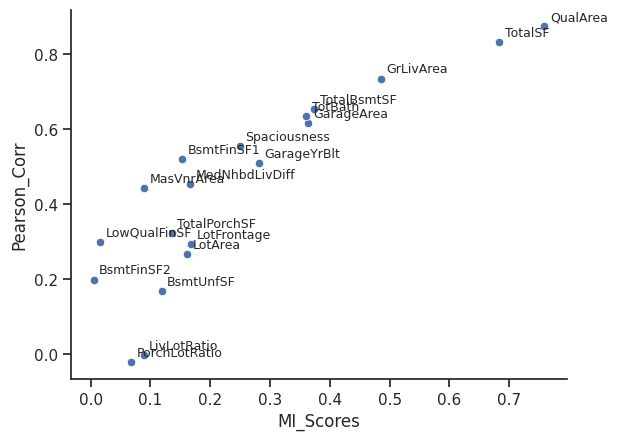

In [165]:
base_cols  = X.select_dtypes('float')
target_col = y

column_scores = pd.DataFrame(get_mi_scores(base_cols, target_col))
column_scores = column_scores.join(pd.DataFrame(get_pearson_corr(base_cols, target_col, exclude_zeros=True)))

# display results in a scatter plot
fig, ax = plt.subplots()

sns.scatterplot(column_scores, x='MI_Scores', y='Pearson_Corr', ax=ax)
sns.despine()

for row in column_scores.iterrows():
    ax.annotate(str(row[0]), xy=(row[1]['MI_Scores'], row[1]['Pearson_Corr']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

plt.show()

In [194]:
def drop_uninformative(df, mi_scores, drop_threshold, verbose=False):
    '''
    Remove columns with 0 mutual information
    '''
    if verbose:
        print('Uninformative columns that will be dropped:')
        print(mi_scores.index[mi_scores.le(drop_threshold)].to_list())
    return df.loc[:, mi_scores > drop_threshold]


def error_given_drop_threshold(thresdhold):
    X = train.copy()
    y = X.pop('SalePrice')

    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)

    X.set_flags()
    X = drop_linear_combos(X)

    mi_scores = get_mi_scores(X, y)
    X = drop_uninformative(X, mi_scores, drop_threshold=thresdhold)

    return score_model(X, y)

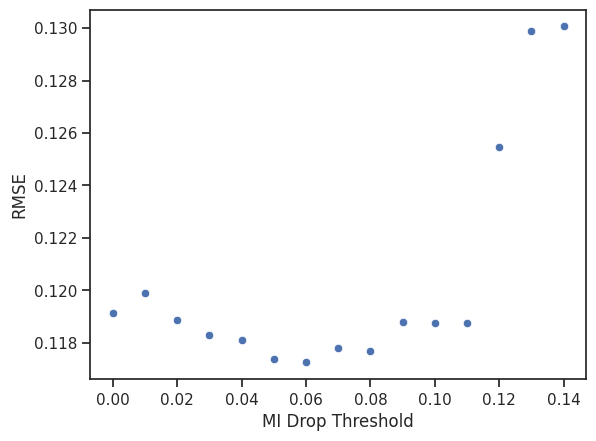

In [196]:
# quick scan to find the best feature drop threshold
test_thresholds = np.arange(0, 0.15, 0.01)

errors = []
for threshold in test_thresholds:
    errors.append(error_given_drop_threshold(threshold))

# plot results
fig, ax = plt.subplots()
sns.scatterplot(x=test_thresholds, y=errors, ax=ax)

ax.set_xlabel('MI Drop Threshold')
ax.set_ylabel('RMSE')

plt.show()

# looks like the optimal choice is about 0.06

In [ ]:
X = train.copy()
y = X.pop('SalePrice')

X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X.set_flags()
X = drop_linear_combos(X)

mi_scores = get_mi_scores(X, y)
X = drop_uninformative(X, mi_scores, drop_threshold=0.06, verbose=True)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Uninformative columns that will be dropped:
['BsmtCond', 'PavedDrive', 'Electrical', 'BldgType', 'BsmtFinType2', 'LandContour', 'ExterCond', 'Condition1', 'KitchenAbvGr', 'RoofStyle', 'Heating', 'BsmtFinSF2', 'LotConfig', 'LowQualFinSF', 'Functional', 'RoofMatl', 'LandSlope', 'Condition2', 'Street', 'Utilities', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Model score: 0.11724 RMSE


## Normalize Right-Skewed Continuous Features

In [ ]:
# have to normalize data. Plot skew and number non-zero entries to see which columns would be best to normalize with a log